In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [2]:
class GreetState(BaseModel):
    message:str =""

In [3]:
graph = StateGraph(GreetState)

##### Nodes: Python functions

In [4]:
def Greet(state: GreetState) -> GreetState:
    state.message = f"Hello, Mr vdev, {state.message}"
    return state

def UpperCase(state: GreetState) -> GreetState:
    state.message = state.message.upper()
    return state



In [5]:
graph.add_node("greet",Greet)
graph.add_node("upperCase", UpperCase)

#### connetion between start node and first node

In [6]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upperCase")
graph.add_edge("upperCase", END)

In [7]:
finalGraph = graph.compile()

In [8]:
res = finalGraph.invoke({"message": "how are you doing?"})

In [9]:
res

{'message': 'HELLO, MR VDEV, HOW ARE YOU DOING?'}

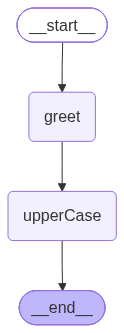

In [10]:
# diplay graph
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png() )